# Bibliotecas

In [1]:
!pip install ultralytics -q

In [3]:
import os
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from ultralytics import YOLO
import torch
import random

from collections import Counter
from ultralytics import YOLO
from matplotlib.lines import Line2D

# Baixando Arquivos

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")

print("Path to dataset files:", path)

c:\Users\Maiquel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3


# Script Anti-Inatividade

In [8]:
%%javascript
function ClickConnect() {
    console.log("Mantendo a conexão viva... " + new Date().toLocaleTimeString());
    const connectButton = document.querySelector("colab-connect-button");
    if (connectButton) {
        connectButton.click();
    } else {
        const toolbarButton = document.querySelector("colab-toolbar-button");
        if (toolbarButton) toolbarButton.click();
    }
}
setInterval(ClickConnect, 60000);

<IPython.core.display.Javascript object>

# Localizando Pastas

In [9]:
print(f"O path fornecido é: {path}")

def find_train_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'labels' in os.listdir(os.path.join(root, 'train')):
            return os.path.join(root, 'train')
    return None

real_train_path = find_train_folder(path)

if real_train_path:
    print(f"✅ Sucesso! A pasta de treino real é: {real_train_path}")
    # Atualizando o caminho base para o script
    base_data_path = os.path.dirname(real_train_path)
else:
    print("❌ Não encontramos a pasta 'train/labels'. Vamos listar o que tem no diretório:")
    print(os.listdir(path))

O path fornecido é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3
✅ Sucesso! A pasta de treino real é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data\train


# Auditoria dos Dados

🔍 Analisando... isso pode levar alguns segundos.


C:\Users\Maiquel\AppData\Local\Temp\ipykernel_2880\3678547624.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')


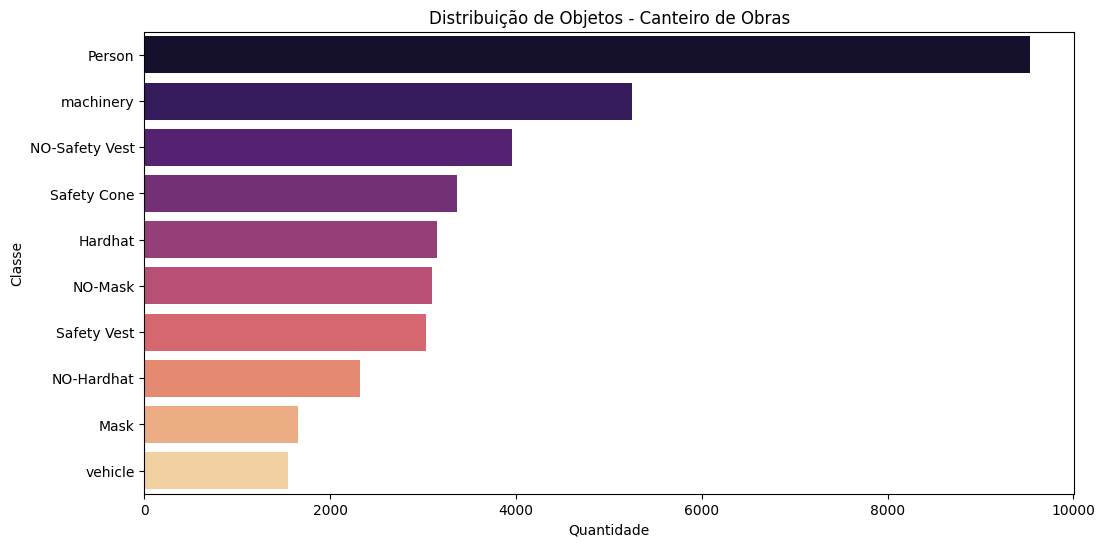


📊 Resumo Numérico:
           Classe  Quantidade
2          Person        9532
7       machinery        5247
5  NO-Safety Vest        3962
8     Safety Cone        3366
0         Hardhat        3145
1         NO-Mask        3097
6     Safety Vest        3033
4      NO-Hardhat        2317
3            Mask        1651
9         vehicle        1545


In [10]:
target_path = base_data_path if 'base_data_path' in locals() else path

# Definição do mapa de classes (ID -> Nome)
class_map = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Cone',
    7: 'Safety Vest',
    8: 'machinery',
    9: 'vehicle'
}

def analyze_labels_v2(dataset_path, split):
    possible_paths = [
        os.path.join(dataset_path, split, 'labels'),
        os.path.join(dataset_path, 'css-data', split, 'labels'),
    ]

    label_path = None
    for p in possible_paths:
        if os.path.exists(p):
            label_path = p
            break

    counts = Counter()
    if not label_path:
        print(f"⚠️ Pasta de labels não encontrada para: {split}")
        return counts

    for label_file in os.listdir(label_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_path, label_file), 'r') as f:
                for line in f:
                    try:
                        class_id = int(line.split()[0])
                        counts[class_id] += 1
                    except:
                        continue
    return counts

# Executar a contagem
print("🔍 Analisando... isso pode levar alguns segundos.")
train_counts = analyze_labels_v2(target_path, 'train')

if not train_counts:
    print("❌ Erro: Nenhuma etiqueta foi encontrada. Verifique se o dataset foi baixado corretamente.")
else:
    # Criar DataFrame e Gráfico
    df_counts = pd.DataFrame([
        {'Classe': class_map.get(k, f'Unknown-{k}'), 'Quantidade': v}
        for k, v in train_counts.items()
    ])

    df_counts = df_counts.sort_values(by='Quantidade', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')
    plt.title('Distribuição de Objetos - Canteiro de Obras')
    plt.show()

    print("\n📊 Resumo Numérico:")
    print(df_counts)

# Organização e validação das fotos

In [11]:
target_path = r'C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data'

# Define onde salvar o arquivo YAML (na sua pasta atual do VS Code)
yaml_path = os.path.join(os.getcwd(), 'seguranca.yaml')


data_config = {
    'train': os.path.join(target_path, 'train', 'images'),
    'val': os.path.join(target_path, 'valid', 'images'),
    'test': os.path.join(target_path, 'test', 'images'),
    'nc': 10,
    'names': [class_map[i] for i in range(10)]
}

# Salva o arquivo no Windows
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"✅ Arquivo de configuração criado em: {yaml_path}")

✅ Arquivo de configuração criado em: c:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\seguranca.yaml


# Treinamento do Modelo

In [12]:
model = YOLO('yolov8n.pt')

print("🚀 Iniciando o treinamento na sua RTX 3050...")

# Iniciar o treinamento especializado
results = model.train(
    data='seguranca.yaml',    # Alterado: agora aponta para o arquivo local no seu Windows
    epochs=50,                # Número de épocas
    imgsz=640,                # Resolução das imagens
    batch=8,                  # Sugestão: 8 é mais seguro para os 6GB de VRAM da sua placa
    name='seguranca_obra_v1', 
    device=0                  # Mantemos o 0 para usar a GPU que acabamos de configurar
)

🚀 Iniciando o treinamento na sua RTX 3050...
New https://pypi.org/project/ultralytics/8.4.10 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.9  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9

KeyboardInterrupt: 

# Matriz de Confusão e Curvas de Treinamento

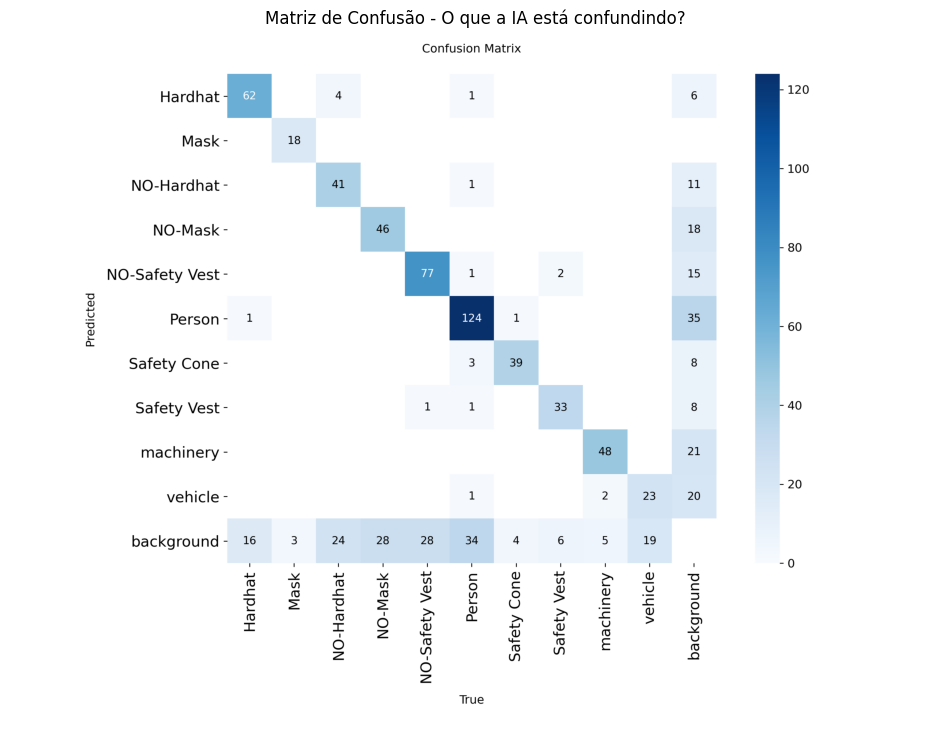

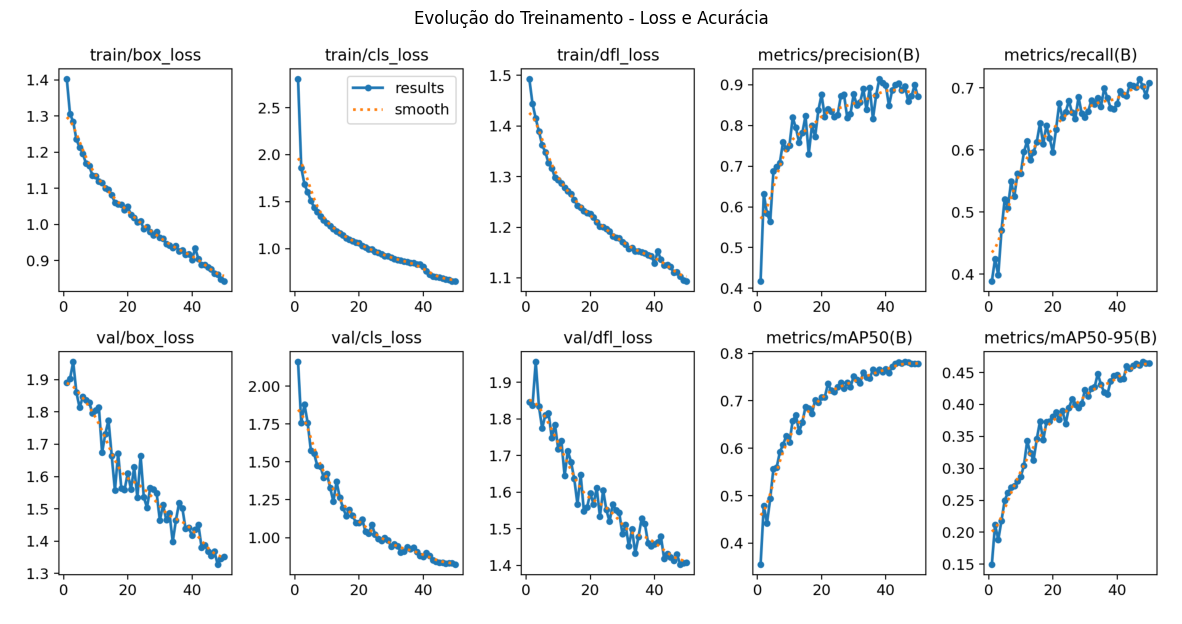

In [ ]:
# Definir o caminho onde os resultados foram salvos
res_path = '/content/runs/detect/seguranca_obra_v1'

# Mostrar a Matriz de Confusão
plt.figure(figsize=(12, 10))
img_matrix = mpimg.imread(os.path.join(res_path, 'confusion_matrix.png'))
plt.imshow(img_matrix)
plt.title("Matriz de Confusão - O que a IA está confundindo?")
plt.axis('off')
plt.show()

# Mostrar os gráficos de treino (Loss e mAP)
plt.figure(figsize=(15, 10))
img_results = mpimg.imread(os.path.join(res_path, 'results.png'))
plt.imshow(img_results)
plt.title("Evolução do Treinamento - Loss e Acurácia")
plt.axis('off')
plt.show()

# Fine-Tuning

In [ ]:
# Carregar os pesos que já são bons (o melhor do treino anterior)
# Isso garante que não começamos do zero, mas do ponto mais inteligente
modelo_pro = YOLO('/content/runs/detect/seguranca_obra_v1/weights/best.pt')

# Iniciar o Refinamento (Fine-Tuning Avançado)
results_v2 = modelo_pro.train(
    data='/content/data.yaml',
    epochs=100,              # Mais tempo para entender os padrões difíceis
    lr0=0.001,               # Taxa de aprendizado menor (mais cautela)
    patience=20,             # Se o modelo parar de melhorar por 20 épocas, ele para sozinho
    imgsz=640,
    batch=16,
    augment=True,            # Ativa distorções de imagem para simular poeira e luz forte
    name='seguranca_obra_v2_pro',
    device=0
)

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/seguranca_obra_v1/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seguranca_obra_v2_pro, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

# Avaliação do Modelo

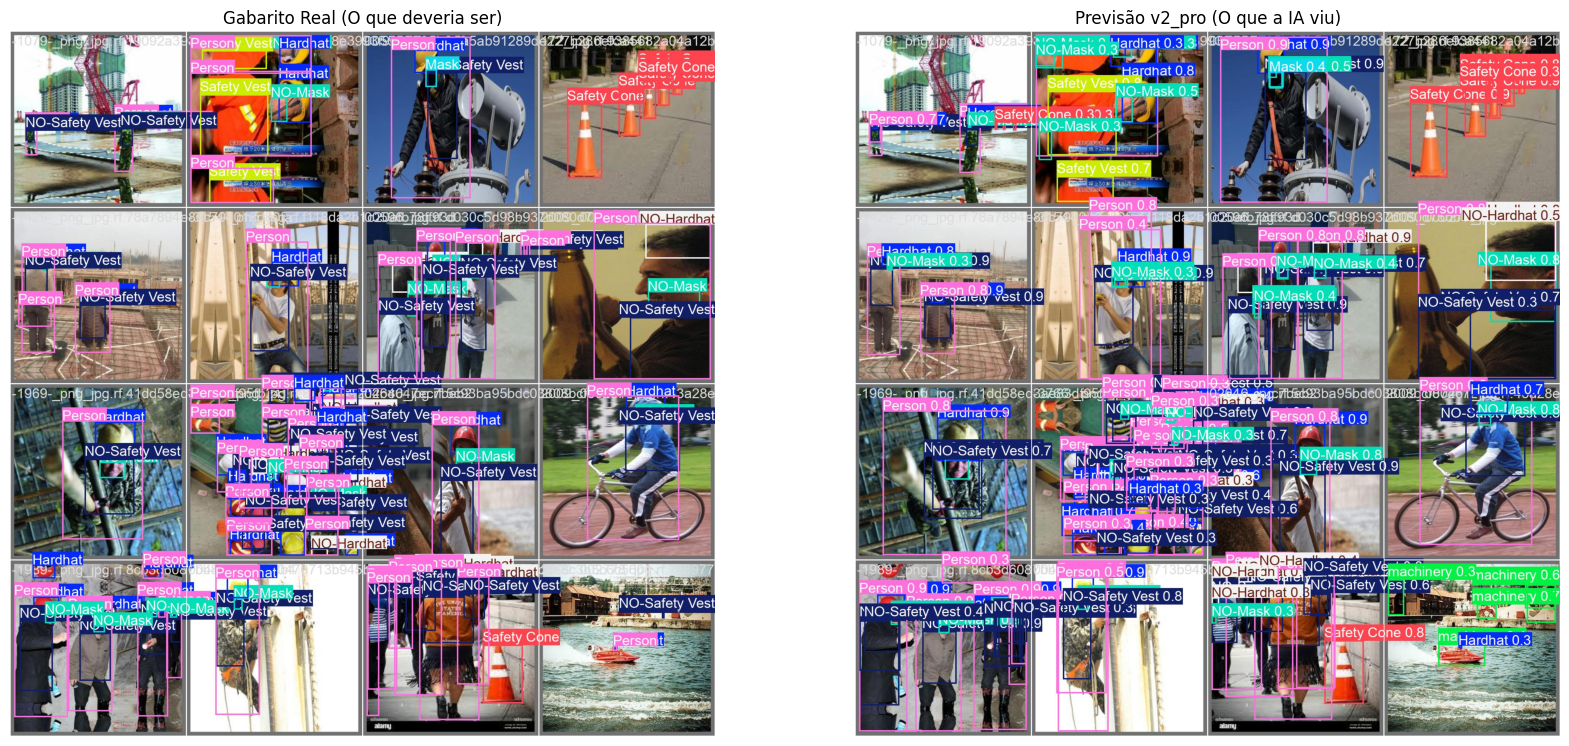

In [ ]:
# Caminho dos resultados da versão Pro
res_path_v2 = '/content/runs/detect/seguranca_obra_v2_pro'

# O YOLO salva automaticamente algumas previsões feitas durante a validação
val_image_path = os.path.join(res_path_v2, 'val_batch0_labels.jpg') # Labels reais
pred_image_path = os.path.join(res_path_v2, 'val_batch0_pred.jpg') # O que a IA previu

if os.path.exists(pred_image_path):
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(mpimg.imread(val_image_path))
    plt.title("Gabarito Real (O que deveria ser)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mpimg.imread(pred_image_path))
    plt.title("Previsão v2_pro (O que a IA viu)")
    plt.axis('off')

    plt.show()
else:
    print("Aguarde o final do processamento ou verifique se o caminho está correto.")

/tmp/ipython-input-884675797.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)


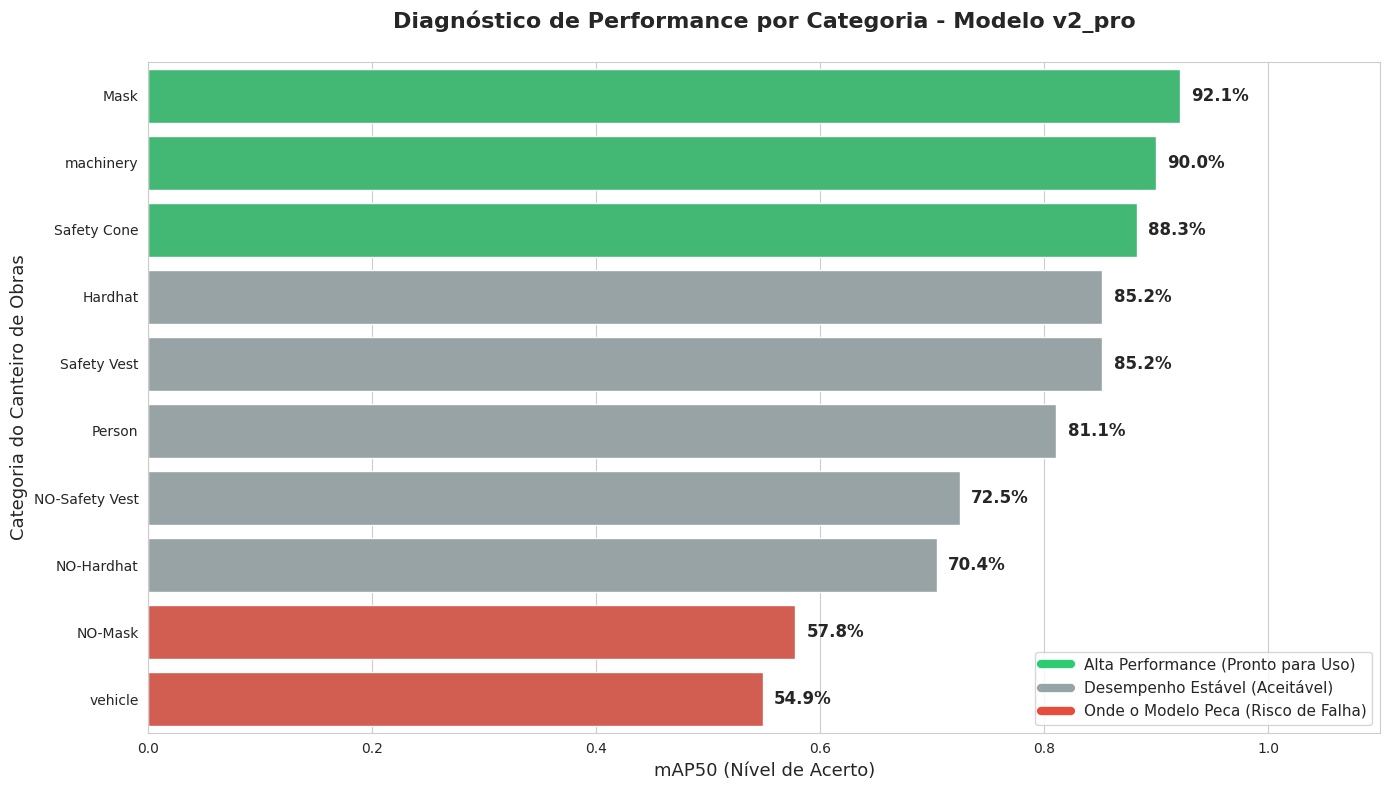

In [ ]:
# Prepara os dados baseados na sua última validação
# Substituímos os números pelos resultados reais que você obteve
dados_validacao = {
    'Classe': [
        'Mask', 'machinery', 'Safety Cone', 'Hardhat', 'Safety Vest',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.921, 0.900, 0.883, 0.852, 0.852,
        0.811, 0.725, 0.704, 0.578, 0.549
    ]
}

df_eval = pd.DataFrame(dados_validacao).sort_values(by='mAP50', ascending=False)

# Definir a lógica de cores profissional
# Verde: Acima de 88% | Vermelho: Abaixo de 60% | Cinza: O resto
cores_mapa = []
for valor in df_eval['mAP50']:
    if valor >= 0.88:
        cores_mapa.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_mapa.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_mapa.append('#95a5a6')  # Cinza (Estável)

# Cria a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)

# Adiciona as porcentagens no final de cada barra para facilitar a leitura
for i, valor in enumerate(df_eval['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

# Customização de Títulos e Eixos
plt.title('Diagnóstico de Performance por Categoria - Modelo v2_pro', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Adicionar uma legenda explicativa
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Treinando com o YOLOv8s (Small)



*   **YOLOv8s (Small):** 11 milhões de parâmetros. Muito mais preciso para detalhes pequenos como o capacete, mantendo uma boa velocidade.
*   **YOLOv8m (Medium):** 25 milhões de parâmetros. Aqui é onde a IA começa a entender contextos complexos (como distinguir um balde amarelo de um capacete amarelo).



In [ ]:
# Carregar o modelo Small pré-treinado
# O 's' no nome indica a versão Small, que é mais potente que a Nano 'n'
model_small = YOLO('yolov8s.pt')

# Inicia o treinamento de Alta Performance
print("🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!")

results_v3 = model_small.train(
    data='/content/data.yaml',    # O mapa que já criamos
    epochs=100,                   # 100 épocas para extrair o máximo do modelo
    imgsz=640,                    # Resolução padrão profissional
    batch=16,                     # Processa 16 imagens por vez
    patience=25,                  # Para se não houver melhora em 25 rodadas
    name='seguranca_obra_v3_small',
    device=0                      # Usa a GPU T4
)

🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seguranca_obra_v3_small, nbs=64, nms=False, opset=None, o

# Avaliando Modelo

/tmp/ipython-input-2346226717.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)


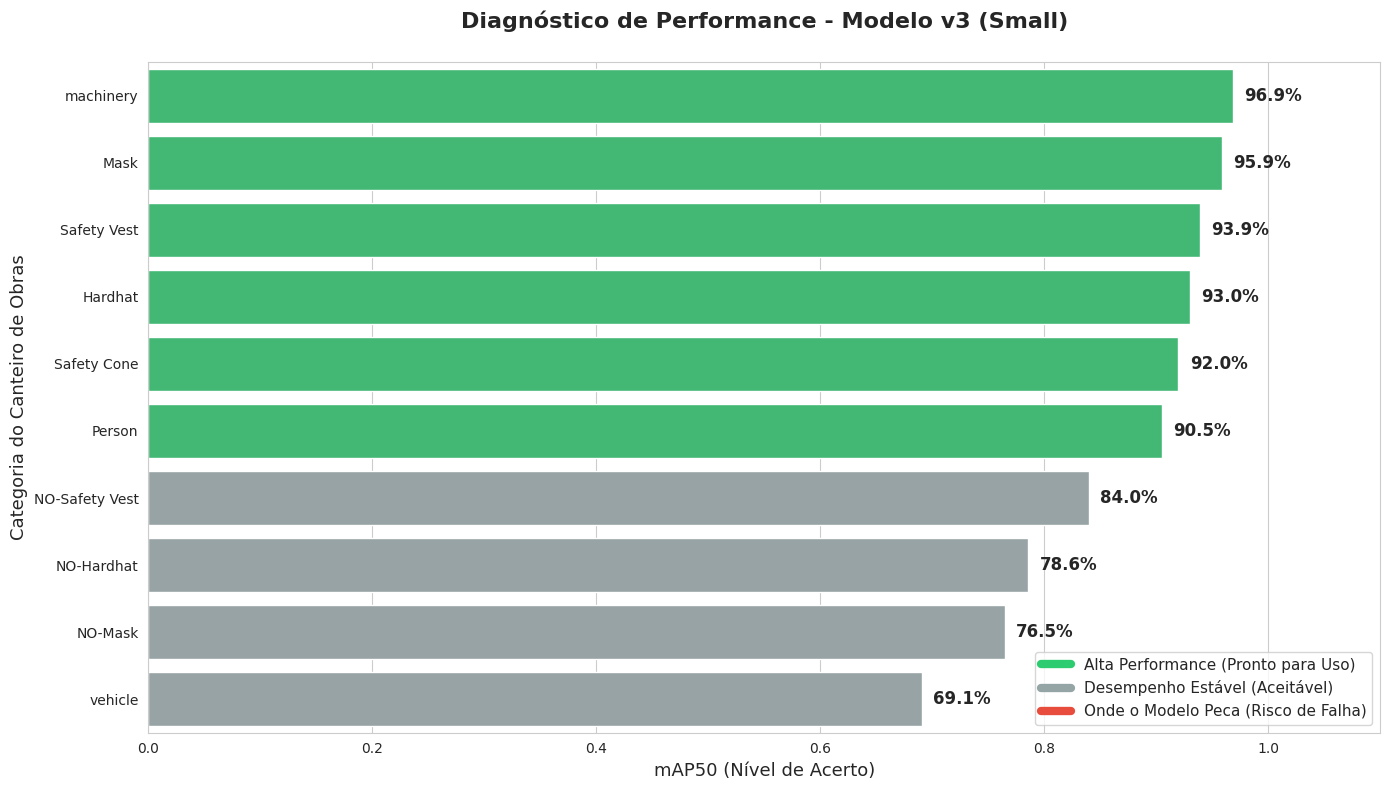

In [ ]:
dados_v3 = {
    'Classe': [
        'machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.969, 0.959, 0.939, 0.930, 0.920,
        0.905, 0.840, 0.786, 0.765, 0.691
    ]
}

df_v3 = pd.DataFrame(dados_v3).sort_values(by='mAP50', ascending=False)

# Lógica de cores (Verde: >= 88% | Vermelho: <= 60% | Cinza: Meio)
cores_v3 = []
for valor in df_v3['mAP50']:
    if valor >= 0.88:
        cores_v3.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_v3.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_v3.append('#95a5a6')  # Cinza (Estável)

# Gerar a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)

# Adicionar valores nas barras
for i, valor in enumerate(df_v3['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

plt.title('Diagnóstico de Performance - Modelo v3 (Small)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Legenda Profissional
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Limpar a Memória

In [ ]:
import torch
import gc

# Limpa o cache da GPU e a memória do Python
gc.collect()
torch.cuda.empty_cache()
print("🧹 Memória Limpa")

🧹 Memória limpa e pronta para o próximo round!


# Importando Arquivos do Modelo Anterior

In [ ]:
from google.colab import files
import os

print("Selecione os arquivos best.pt e last.pt do seu computador:")
uploaded = files.upload()

# Verifica se os arquivos subiram corretamente
for fn in uploaded.keys():
  print('Arquivo "{name}" com tamanho de {length} bytes enviado com sucesso!'.format(
      name=fn, length=len(uploaded[fn])))

Selecione os arquivos best.pt e last.pt do seu computador:


Saving last.pt to last.pt
Saving best.pt to best.pt
Arquivo "last.pt" com tamanho de 22531690 bytes enviado com sucesso!
Arquivo "best.pt" com tamanho de 22531690 bytes enviado com sucesso!


# Treinando com o YOLOv8s (Medium)

In [ ]:
# Ele é mais pesado que o Small, então a detecção será mais 'inteligente'
model_medium = YOLO('yolov8m.pt')

# 2. Iniciar o treinamento de Nível Especialista
print("🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.")

results_v4 = model_medium.train(
    data='/content/data.yaml',    # O mesmo mapa de dados que estamos usando
    epochs=100,                   # 100 rodadas para o modelo 'maturar' bem
    imgsz=640,                    # Resolução padrão de alta qualidade
    batch=8,                     # Processa 16 imagens por vez (se der erro de memória, mude para 8)
    patience=30,                  # Dá tempo para o modelo aprender padrões difíceis
    augment=True,                 # Ativa filtros de luz e poeira para simular o ambiente de obra
    name='seguranca_obra_v4_medium',
    device=0                      # Utiliza a GPU Tesla T4 do Colab
)

🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seguranca_obra_v4_medium, nbs=64, nms=False, opset=Non